# Purpose:
- Running another round of landmark extension.
- Based on the 1st iteration, where no GFP threshold was used.
    - Now set the threshold based on QC'ed ROIs.
    - Now simply use distance matrix. Don't iterate, make one matrix, and match all at once.
        - This reduces mismatching between nearby cells.
- Metrics:
    - How many more co-registered cells after another iteration?
    - How much does additional manual step help?
# Protocol:
- Filter HCR data based on spot counts and density
- Find nearest matches (greedy method)

# Update: 11/18/2025 JK
- Generic iteration (2nd ~ )
- Choose between nearest point (after filtering) or finding max HCR value (either count or density) within the neighborhood.
# Update: 03/02/2026 JK
- Reducing number of activated lanmarks.
    - Filter randomly within volume grids.
    - Using landmark_filtering.py

In [1]:
import os
import zarr
import numpy as np
import tifffile as tiff
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import Rbf
from scipy.spatial import distance_matrix
import cv2
import os
import json
from pathlib import Path

from manual_coreg_utils import (get_ids_from_landmarks,
                                choose_max_count_nearest_neighbor,
                                one_to_one_matching,
                                )
from landmark_filtering import (get_volume_bounds_from_data,
                                grid_sample_landmarks,
                                visualize_landmark_distribution,
                                )

DATA_DIR = Path('/root/capsule/data/')

%load_ext autoreload
%autoreload 2

In [36]:
# Setting
subject_id = 790322
czstack_date = '2025-07-10'
save_dir = Path(f'/root/capsule/scratch/{subject_id}_{czstack_date}_coreg_cpsam/')

###
# IMPORTANT! #
###
# Parameters
current_iter = 6
prev_iter = current_iter -1
filter_hcr_rois = True
filter_rate_from_min = 1.2
protocol = 'nearest_point' # 'nearest_point' or 'nearest_max'
num_neighbor = 5 # used for protocol 'nearest_max'
hcr_value_feature = 'density' # 'density' or 'count', used for protocol 'nearest_max'
sampling_landmark_threshold = 500 # if more than this number of landmarks, then filter them
interior_keep_proportion=0.1
edge_keep_proportion=0.2
min_landmarks_per_grid=2

assert protocol in ['nearest_point', 'nearest_max']
assert hcr_value_feature in ['density', 'count']

# Loading
filepaths_iter_json = save_dir / f'{subject_id}_{czstack_date}_filepaths_iter.json'
with open(filepaths_iter_json, 'r') as f:
    filepaths_dict = json.load(f)
for key in filepaths_dict:
    filepaths_dict[key] = Path(filepaths_dict[key])
    assert filepaths_dict[key].exists()
print(filepaths_dict.keys())
# make variables named after each filepath
for key in filepaths_dict:
    globals()[key] = filepaths_dict[key]
hcr_dir = fused_json_file.parent

dict_keys(['czstack_reg_path', 'czstack_reg_dim_swapped_path', 'czstack_seg_path', 'czstack_seg_outline_path', 'czstack_centroid_path', 'hcr_centroid_path', 'hcr_segmentation_metrics_path', 'fused_json_file', 'spot_488_counts_path'])


# Repeat data loading

In [3]:
# Find spot data
spot_488_counts = pd.read_csv(spot_488_counts_path, index_col=0)

# Get HCR centroid and scales
with open(fused_json_file, 'r') as file:
    data = json.load(file)
scale_x = data['dimensions']['x'][0]*4e6
scale_y = data['dimensions']['y'][0]*4e6
scale_z = data['dimensions']['z'][0]*1e6

HCR_cell_centroids = np.load(hcr_centroid_path)

HCR_cell_ids = HCR_cell_centroids[:,3]
HCR_cell_centroids = HCR_cell_centroids[:,:-1]

HCR_cell_centroids_df = pd.DataFrame()
HCR_cell_centroids_df['hcr_cell_id'] = HCR_cell_ids
HCR_cell_centroids_df['hcr_z'] = HCR_cell_centroids[:,0]
HCR_cell_centroids_df['hcr_y'] = HCR_cell_centroids[:,1]
HCR_cell_centroids_df['hcr_x'] = HCR_cell_centroids[:,2]
HCR_cell_centroids_df.set_index('hcr_cell_id', inplace=True)


# Get cortical z-stack centroids
czstack_cell_centroids_df = pd.read_csv(czstack_centroid_path, index_col=0)


## Get landmarks from the previous iteration
- Get previously matched IDs
- Apply transformation

In [37]:
# Get landmarks from the previous iteration
if prev_iter == 0:
    landmarks_file = save_dir / f'{subject_id}_{czstack_date}_landmarks.csv'
else:
    # landmarks_file = save_dir / f'{subject_id}_{czstack_date}_landmarks_matched_ext_iter{prev_iter}_reordered_qced.csv'
    landmarks_file = save_dir / f'{subject_id}_{czstack_date}_landmarks_matched_ext_iter{prev_iter}_qced.csv'
    if not landmarks_file.exists():
        raise FileNotFoundError

current_landmarks = pd.read_csv(landmarks_file,header=None)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
current_landmarks.columns = columns
prev_qced_ids = current_landmarks[current_landmarks.ids.str.startswith('qced')].ids.values
prev_qced_ids = [qcid.replace('qced_','') for qcid in prev_qced_ids]
current_landmarks.loc[current_landmarks.ids.str.startswith('qced'), 'active'] = True
current_landmarks.loc[current_landmarks.ids.str.startswith('qced'), 'ids'] = prev_qced_ids

num_roi_points = len(czstack_cell_centroids_df)
if num_roi_points < sum(current_landmarks.ids.str.startswith('cz')):
    raise ValueError(f'More landmarks ({sum(current_landmarks.ids.str.startswith("cz"))}) than total ROIs ({num_roi_points}). Please check the landmarks file and the czstack centroids file.')
elif num_roi_points > sum(current_landmarks.ids.str.startswith('cz')):
    print(f'Less landmarks ({sum(current_landmarks.ids.str.startswith("cz"))}) than total ROIs ({num_roi_points}).')
    print('This can happen when qced landmarks are removed during the previous iteration')
    print('Add removed czstack landmarks back.')
    czstack_ids_in_landmarks = get_ids_from_landmarks(current_landmarks)[0]
    all_czstack_ids = czstack_cell_centroids_df.index.to_list()
    removed_czstack_ids = list(set(all_czstack_ids) - set(czstack_ids_in_landmarks))
    for removed_id in removed_czstack_ids:
        new_row = {'ids': f'cz_{removed_id}-hcr_nan',
                   'active': False,
                   'czstack_x': czstack_cell_centroids_df.loc[removed_id, 'czstack_x'],
                   'czstack_y': czstack_cell_centroids_df.loc[removed_id, 'czstack_y'],
                   'czstack_z': czstack_cell_centroids_df.loc[removed_id, 'czstack_z'],
                   'hcr_x': np.nan,
                   'hcr_y': np.nan,
                   'hcr_z': np.nan}
        current_landmarks = pd.concat([current_landmarks, pd.DataFrame([new_row])], ignore_index=True)
assert sum(current_landmarks.ids.str.startswith('cz')) == num_roi_points

active_landmarks = current_landmarks.query('active')

points_zstack = active_landmarks[['czstack_x', 'czstack_y', 'czstack_z']].values.astype(np.float32)
points_HCR = active_landmarks[['hcr_x', 'hcr_y', 'hcr_z']].values.astype(np.float32)

matched_czstack_ids, matched_hcr_ids = get_ids_from_landmarks(active_landmarks)
leftover_czstack_df = czstack_cell_centroids_df.loc[~czstack_cell_centroids_df.index.isin(matched_czstack_ids)].copy()
leftover_czstack_ids = leftover_czstack_df.index.to_list()
leftover_czstack_cell_centroids = np.vstack(leftover_czstack_df[['czstack_x','czstack_y','czstack_z']].values)

interp_zstacktoHCR_0 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,0],
                           function='thin_plate')
interp_zstacktoHCR_1 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,1],
                           function='thin_plate')
interp_zstacktoHCR_2 = Rbf(points_zstack[:, 0], points_zstack[:, 1], points_zstack[:, 2], points_HCR[:,2],
                           function='thin_plate')

HCR_centroids_est = np.zeros_like(leftover_czstack_cell_centroids)

HCR_centroids_est[:,0] = interp_zstacktoHCR_0(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_x
HCR_centroids_est[:,1] = interp_zstacktoHCR_1(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_y
HCR_centroids_est[:,2] = interp_zstacktoHCR_2(leftover_czstack_cell_centroids[:, 0],
                                              leftover_czstack_cell_centroids[:, 1],
                                              leftover_czstack_cell_centroids[:, 2]) / scale_z

if num_roi_points > 0:
    print(f'{len(matched_czstack_ids)} matched in the previous iteration {prev_iter} out of total {num_roi_points} ROIs.')
    print(f'{(len(matched_czstack_ids) / num_roi_points)*100:.2f} %')
else:
    assert prev_iter==0
    print(f'This is the first automatic matching iteration.')

Less landmarks (978) than total ROIs (1016).
This can happen when qced landmarks are removed during the previous iteration
Add removed czstack landmarks back.
778 matched in the previous iteration 5 out of total 1016 ROIs.
76.57 %


## Where are the leftover centroids?

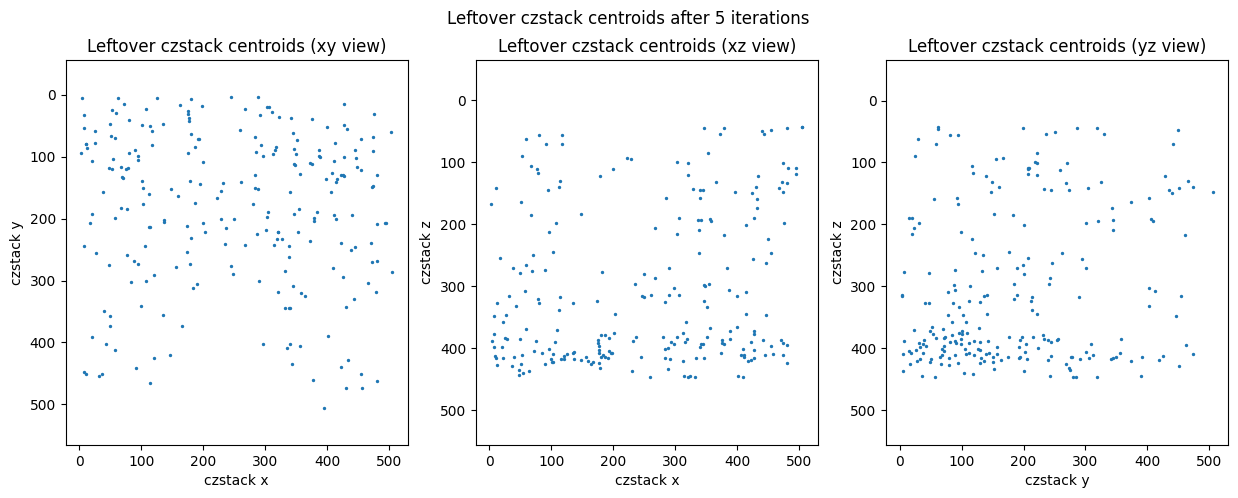

In [38]:
# plot density of leftover czstack centroids from 3 different views
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,1], s=2)
axs[0].set_xlabel('czstack x')
axs[0].set_ylabel('czstack y')
axs[0].set_title('Leftover czstack centroids (xy view)')
axs[1].scatter(leftover_czstack_cell_centroids[:,0], leftover_czstack_cell_centroids[:,2], s=2)
axs[1].set_xlabel('czstack x')
axs[1].set_ylabel('czstack z')
axs[1].set_title('Leftover czstack centroids (xz view)')
axs[2].scatter(leftover_czstack_cell_centroids[:,1], leftover_czstack_cell_centroids[:,2], s=2)
axs[2].set_xlabel('czstack y')
axs[2].set_ylabel('czstack z')
axs[2].set_title('Leftover czstack centroids (yz view)')
for ax in axs:
    # make the origin at the upper left corner
    ax.invert_yaxis()
    ax.axis('equal')
fig.suptitle(f'Leftover czstack centroids after {prev_iter} iterations')
plt.show()

# Estimating based on GFP count after filtering
- Picking the nearest HCR segmentation
- filtering based on the matched cells in the previous round

In [29]:
# filtering
matched_spot_counts = spot_488_counts.loc[matched_hcr_ids]
nonmatched_spot_counts = spot_488_counts.drop(index=matched_hcr_ids)
if filter_hcr_rois:
    print('Filtering non-matched HCR ROIs based on spot counts and density thresholds...')
    print(f'with filter rate from minimum {filter_rate_from_min}')
    print('Good for protocol "nearest_point"')
    print(f'(current protocol: "{protocol})"')
    min_counts = matched_spot_counts['counts'].min() * filter_rate_from_min
    min_density = matched_spot_counts['density'].min() * filter_rate_from_min
    leftover_spot_counts = nonmatched_spot_counts.query('counts >= @min_counts and density >= @min_density')
else:
    print('Not filtering non-matched HCR ROIs...')
    print('Good for protocol "nearest_max"')
    print(f'(current protocol: "{protocol}")')
    leftover_spot_counts = nonmatched_spot_counts

leftover_HCR_df = pd.merge(leftover_spot_counts, HCR_cell_centroids_df, left_index=True, right_index=True, how='inner')
assert not set(leftover_spot_counts.index.values).intersection(set(matched_spot_counts))

Filtering non-matched HCR ROIs based on spot counts and density thresholds...
with filter rate from minimum 1.2
Good for protocol "nearest_point"
(current protocol: "nearest_max)"


Running protocol "nearest_point"


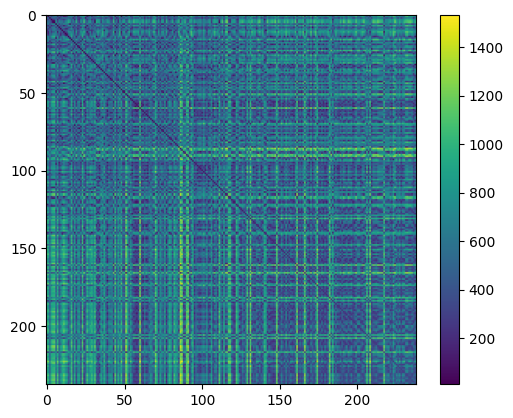

In [39]:
print(f'Running protocol "{protocol}"')
if protocol == 'nearest_point':    
    final_matched_indices, final_matched_distances, dist_matrix = \
        one_to_one_matching(HCR_centroids_est, leftover_HCR_df)
else:
    print(f'Num neighbor: {num_neighbor}')
    print(f'Feature: {hcr_value_feature}')
    final_matched_indices, final_matched_distances, dist_matrix = \
        choose_max_count_nearest_neighbor(HCR_centroids_est, leftover_HCR_df, feature=hcr_value_feature,
            k=num_neighbor, resolve_duplicates=True)

valid_match_mask = final_matched_indices >= 0
valid_source_indices = np.where(valid_match_mask)[0]
valid_target_indices = final_matched_indices[valid_match_mask]
valid_distances = final_matched_distances[valid_match_mask]

sort_order = np.argsort(valid_distances)
    
# Create matrix with matched sources (rows) and their assigned targets (columns)
sorted_sources = valid_source_indices[sort_order]
sorted_targets = valid_target_indices[sort_order]
sorted_dists = valid_distances[sort_order]

# Extract relevant distances for visualization
if len(sorted_sources) > 0:
    matched_dist_matrix = dist_matrix[np.ix_(sorted_sources, sorted_targets)]
    plt.imshow(matched_dist_matrix)
    plt.colorbar()
    plt.show()
else:
    print('No valid matches to visualize.')


In [40]:
# assign matching to matched_cells_df (valid one-to-one matches only)
valid_match_mask = final_matched_indices >= 0
valid_source_indices = np.where(valid_match_mask)[0]
valid_target_indices = final_matched_indices[valid_match_mask]
valid_distances = final_matched_distances[valid_match_mask]

new_matched_hcr_df = leftover_HCR_df.iloc[valid_target_indices].reset_index().copy().rename(columns={'index':'hcr_cell_id'})
new_matched_hcr_df['distance'] = valid_distances

valid_leftover_czstack_df = leftover_czstack_df.iloc[valid_source_indices]
new_matched_hcr_df['czstack_cell_id'] = valid_leftover_czstack_df.index.values
new_matched_hcr_df['czstack_x'] = valid_leftover_czstack_df['czstack_x'].values
new_matched_hcr_df['czstack_y'] = valid_leftover_czstack_df['czstack_y'].values
new_matched_hcr_df['czstack_z'] = valid_leftover_czstack_df['czstack_z'].values

new_matched_hcr_df.sort_values(by='distance', inplace=True)
new_matched_hcr_df.head()

,hcr_cell_id,counts,volume,global_bbox,density,hcr_z,hcr_y,hcr_x,distance,czstack_cell_id,czstack_x,czstack_y,czstack_z
17,8308,697,167632.0,[ 280 5064 4520 437 5340 4768],0.004158,294,1288,1144,8.916951,99,229.187581,155.005175,93.924968
30,18765,420,236976.0,[ 399 5188 3276 571 5424 3536],0.001772,427,1309,838,11.377591,182,471.892526,149.525892,132.383000
77,68075,411,195584.0,[ 801 4176 4292 959 4432 4520],0.002101,814,1058,1085,11.815721,586,290.219614,301.174443,271.103120
28,14987,484,259168.0,[ 370 4120 3840 537 4348 4120],0.001868,390,1042,980,12.494391,175,365.145101,325.721524,131.431951
36,18740,332,187552.0,[ 397 3212 3516 571 3428 3752],0.001770,427,814,894,12.512167,214,430.028794,473.668010,139.778002


## Sample previously QC'ed pairs to improve BigWarp speed

In [41]:

paired_landmarks = active_landmarks[active_landmarks['ids'].str.startswith('cz')].copy()
landmark_sampled = False
if len(paired_landmarks) > sampling_landmark_threshold:
    landmark_sampled = True
    sampling_results = grid_sample_landmarks(
        paired_landmarks,
        interior_keep_proportion=interior_keep_proportion,
        edge_keep_proportion=edge_keep_proportion,
        min_landmarks_per_grid=min_landmarks_per_grid,
    )
    sampled_df = sampling_results['sampled'].copy()
    sampled_df = sampled_df[['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']]

    print(f"\n✓ Final sampled landmarks: {len(sampled_df)} (from {len(paired_landmarks)})")
    print(f"✓ Interior: {sampling_results['stats']['sampled_interior']} kept from {sampling_results['stats']['interior']} ({100*sampling_results['stats']['sampled_interior']/max(1, sampling_results['stats']['interior']):.1f}%)")
    print(f"✓ Edge:     {sampling_results['stats']['sampled_edge']} kept from {sampling_results['stats']['edge']} ({100*sampling_results['stats']['sampled_edge']/max(1, sampling_results['stats']['edge']):.1f}%)")
    print(f"✓ Overall reduction: {sampling_results['stats']['reduction_pct']:.1f}%")
else:
    print(f"# QCed landmarks {len(paired_landmarks)} less then sampling threshold {sampling_landmark_threshold}")
    print(f'No sampling applied')

Volume bounds from data:
  X: 2 - 504 pixels
  Y: 4 - 508 pixels
  Z: 48 - 379 pixels

Edge landmarks: 189 (24.3%)
Interior landmarks: 589 (75.7%)

Grid cells:
  X: 7 cells × 75 pixels
  Y: 7 cells × 75 pixels
  Z: 4 cells × 100 pixels
  Total: 196 cells
  Min landmarks per occupied cell: 2


✓ Final sampled landmarks: 405 (from 778)
✓ Interior: 256 kept from 589 (43.5%)
✓ Edge:     149 kept from 189 (78.8%)
✓ Overall reduction: 47.9%


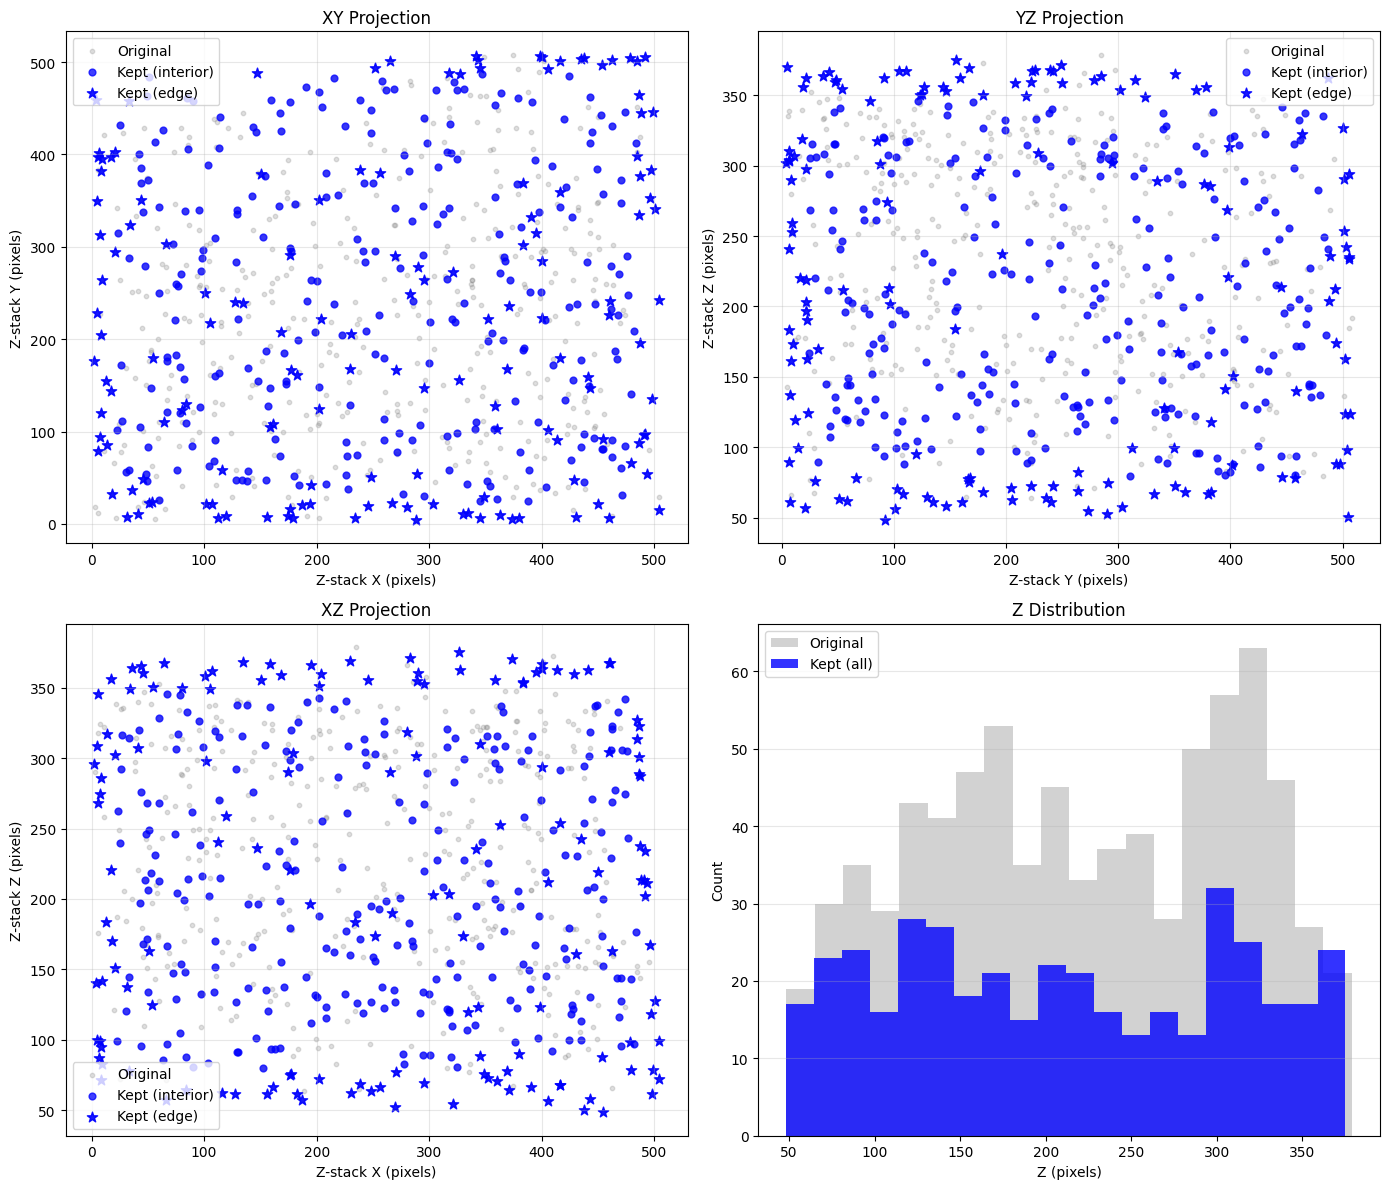

In [42]:
# optionally visualize the distribution of landmarks before/after filtering
if landmark_sampled:
    fig = visualize_landmark_distribution(paired_landmarks, sampling_results)

In [43]:
save_fn = save_dir / f'{subject_id}_{czstack_date}_landmarks_matched_ext_iter{current_iter}.csv'
assert not save_fn.exists(), f'File {save_fn} exists already!'


landmarks_ext = pd.DataFrame()

landmarks_ext[0] = ['cz'+str(int(new_matched_hcr_df['czstack_cell_id'].iloc[i]))+'-hcr'+str(int(new_matched_hcr_df['hcr_cell_id'].iloc[i])) for i in range(len(new_matched_hcr_df))]

landmarks_ext[1] = False
landmarks_ext[2] = new_matched_hcr_df['czstack_x'].values
landmarks_ext[3] = new_matched_hcr_df['czstack_y'].values
landmarks_ext[4] = new_matched_hcr_df['czstack_z'].values
landmarks_ext[5] = new_matched_hcr_df['hcr_x'].values * scale_x
landmarks_ext[6] = new_matched_hcr_df['hcr_y'].values * scale_y
landmarks_ext[7] = new_matched_hcr_df['hcr_z'].values * scale_z

columns = np.arange(8)

qced_landmarks = active_landmarks[active_landmarks.ids.str.startswith('cz')].copy()
qced_landmarks = qced_landmarks.sort_values(by='ids')
qced_landmarks_ids = qced_landmarks.ids.values
qced_landmarks_ids = [f'qced_{x}' for x in qced_landmarks_ids]
qced_landmarks.loc[qced_landmarks.ids.str.startswith('cz'), 'ids'] = qced_landmarks_ids
manual_landmarks = active_landmarks[active_landmarks.ids.str.startswith('Pt')]

if landmark_sampled:    
    sampled_ids = sampled_df.ids.values
    sampled_ids = [f'qced_{x}' for x in sampled_ids]
    qced_landmarks.loc[~qced_landmarks.ids.isin(sampled_ids), 'active'] = False
prev_landmarks = pd.concat([qced_landmarks, manual_landmarks])
prev_landmarks.columns = columns
landmarks_ext = pd.concat([landmarks_ext, prev_landmarks])
print(f'Previously QCed pairs: {len(matched_czstack_ids)}')
print(f'Total active landmarks: {len(landmarks_ext[landmarks_ext[1]])}')
print(f'Number of pairs to QC: {len(leftover_czstack_ids)}')


landmarks_ext.to_csv(save_fn, index=False, header=False)
print(f'Updated landmarks with estimation saved to {save_fn}')
landmarks_ext.head()

Previously QCed pairs: 778
Total active landmarks: 437
Number of pairs to QC: 238
Updated landmarks with estimation saved to /root/capsule/scratch/790322_2025-07-10_coreg_cpsam/790322_2025-07-10_landmarks_matched_ext_iter6.csv


,0,1,2,3,4,5,6,7
0,cz99-hcr8308,False,229.187581,155.005175,93.924968,1121.374332,1262.526346,294.0
1,cz182-hcr18765,False,471.892526,149.525892,132.383000,821.426303,1283.111015,427.0
2,cz586-hcr68075,False,290.219614,301.174443,271.103120,1063.541216,1037.075213,814.0
3,cz175-hcr14987,False,365.145101,325.721524,131.431951,960.617872,1021.391656,390.0
4,cz214-hcr18740,False,430.028794,473.668010,139.778002,876.318753,797.900967,427.0


# Save parameters

In [44]:
iter_param_fn = save_dir / f'{subject_id}_{czstack_date}_iter{current_iter}_params.json'
num_matched_prev = len(matched_czstack_ids)
percent_matched_prev = num_matched_prev / num_roi_points

iter_parameter = {'iter_num': current_iter,
                  'filter_hcr_rois': filter_hcr_rois,
                  'filter_rate_from_min': filter_rate_from_min,
                  'protocol': protocol,
                  'num_neighbor': num_neighbor,
                  'hcr_value_feature': hcr_value_feature,
                  'num_matched_prev': num_matched_prev,
                  'percent_matched_prev': percent_matched_prev,
                  'sampling_landmark_threshold': sampling_landmark_threshold,
                  'landmark_sampled': landmark_sampled
                  }
with open(iter_param_fn, 'w') as f:
    json.dump(iter_parameter, f, indent=4)

# Repeat until satisfied
- Usually 4-5 iterations.
- Change settings as necessary

# Save coreg table

In [ ]:
def get_czstack_id(x):
    if x.startswith('cz'):
        return int(x.split('-')[0][2:])
    else:
        return -1


def get_hcr_id(x):
    if x.startswith('cz'):
        return int(x.split('-')[1][3:])
    else:
        return -1

In [ ]:
final_landmarks_file = save_dir / f'{subject_id}_landmarks_matched_ext_iter{current_iter}.csv'
print(f'Saving table from the last landmarks_file {final_landmarks_file}')

save_fn = save_dir / f'{subject_id}_coreg_table.csv'

landmarks = pd.read_csv(final_landmarks_file)
columns = ['ids', 'active', 'czstack_x', 'czstack_y', 'czstack_z', 'hcr_x', 'hcr_y', 'hcr_z']
landmarks.columns = columns


landmarks['czstack_id'] = landmarks.ids.apply(get_czstack_id)
landmarks['hcr_id'] = landmarks.ids.apply(get_hcr_id)
landmarks = landmarks[landmarks.czstack_id != -1]
num_total = len(landmarks)

matched_landmarks = landmarks.query('active')
num_matched = len(matched_landmarks)
print(f'{num_matched} matched out of total {num_total} ROIs.')
print(f'{(num_matched / num_total)*100:.2f} %')

matched_landmarks = matched_landmarks.sort_values(by='czstack_id')[['czstack_id', 'hcr_id']].reset_index(drop=True)
matched_landmarks.to_csv(save_fn, index=False)

# add filepath info
with open(filepaths_json, 'r') as f:
    filepaths_dict = json.load(f)    
filepaths_dict['final_landmarks'] = str(final_landmarks_file)
filepaths_dict['coreg_table'] = str(save_fn)
with open(filepaths_json, 'w') as f:
    json.dump(filepaths_dict, f, indent=4)


Saving table from the last landmarks_file /root/capsule/scratch/767022_2025-03-06_coreg_cpsam/767022_landmarks_matched_ext_iter4.csv
793 matched out of total 925 ROIs.
85.73 %


In [ ]:
final_landmarks_file

PosixPath('/root/capsule/scratch/767022_2025-03-06_coreg_cpsam/767022_landmarks_matched_ext_iter4.csv')

In [ ]:
landmarks.query('czstack_id<0')

,ids,active,czstack_x,czstack_y,czstack_z,hcr_x,hcr_y,hcr_z,czstack_id,hcr_id


In [ ]:
pd.DataFrame(landmarks.query('hcr_id != -1').hcr_id.value_counts()).query('count == 2')

,count
hcr_id,
